
R1s(r) =
+17.4697 * exp(-8.4936 r)
+10.2078 * exp(-4.8788 r)
-7.3550 * r^2 * exp(-15.4660 r)
+32.1360 * r * exp(-7.0500 r)
+0.0079 * r * exp(-2.2640 r)
+0.0014 * r * exp(-1.4747 r)
-0.0002 * r * exp(-1.1639 r)

R2s(r) =
-3.5510 * exp(-8.4936 r)
+9.4467 * exp(-4.8788 r)
-2.3494 * r^2 * exp(-15.4660 r)
-13.8966 * r * exp(-7.0500 r)
-3.5008 * r * exp(-2.2640 r)
-1.7660 * r * exp(-1.4747 r)
-0.2127 * r * exp(-1.1639 r)

R2p(r) =
+1.0632 * r * exp(-7.0500 r)
+1.5316 * r * exp(-3.2275 r)
+1.8933 * r * exp(-2.1908 r)
+1.1863 * r * exp(-1.4413 r)
+0.4299 * r * exp(-1.0242 r)


/tmp/ipykernel_186/3259902109.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)



chi_1s(p) = sqrt(2/pi) * [
    +17.4697 * (2*8.4936) / ((8.4936**2 + p**2)**2)
    +10.2078 * (2*4.8788) / ((4.8788**2 + p**2)**2)
    -7.3550 * (24*15.4660*(15.4660**2 - p**2)) / ((15.4660**2 + p**2)**4)
    +32.1360 * (2*(3*7.0500**2 - p**2)) / ((7.0500**2 + p**2)**3)
    +0.0079 * (2*(3*2.2640**2 - p**2)) / ((2.2640**2 + p**2)**3)
    +0.0014 * (2*(3*1.4747**2 - p**2)) / ((1.4747**2 + p**2)**3)
    -0.0002 * (2*(3*1.1639**2 - p**2)) / ((1.1639**2 + p**2)**3)
]

I_1s(p) = (2/pi) * p**2 * [
    +17.4697 * (2*8.4936) / ((8.4936**2 + p**2)**2)
    +10.2078 * (2*4.8788) / ((4.8788**2 + p**2)**2)
    -7.3550 * (24*15.4660*(15.4660**2 - p**2)) / ((15.4660**2 + p**2)**4)
    +32.1360 * (2*(3*7.0500**2 - p**2)) / ((7.0500**2 + p**2)**3)
    +0.0079 * (2*(3*2.2640**2 - p**2)) / ((2.2640**2 + p**2)**3)
    +0.0014 * (2*(3*1.4747**2 - p**2)) / ((1.4747**2 + p**2)**3)
    -0.0002 * (2*(3*1.1639**2 - p**2)) / ((1.1639**2 + p**2)**3)
]**2

chi_2s(p) = sqrt(2/pi) * [
    -3.5510 * (2*8.4936) / ((8

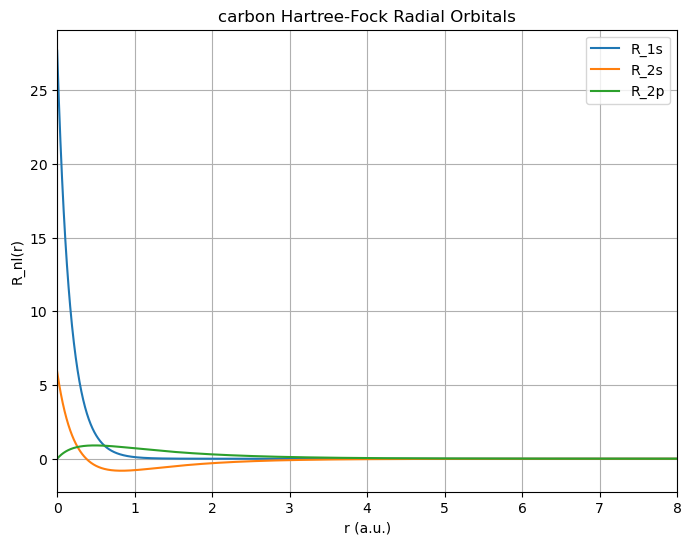

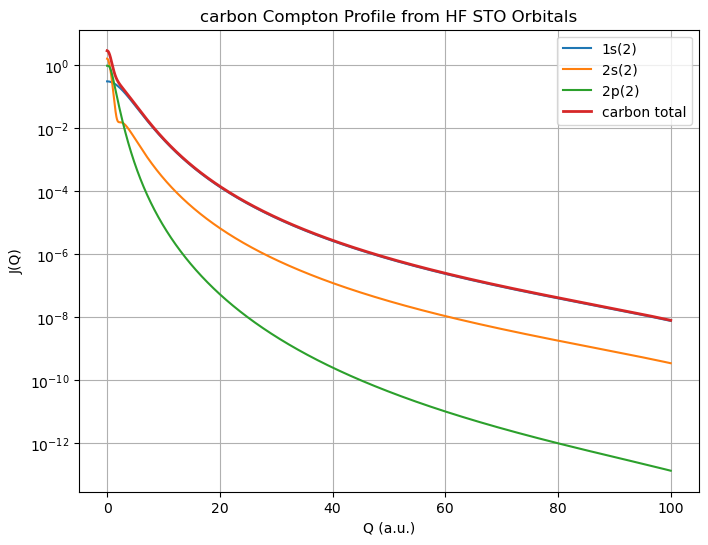

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Carbon Hartree-Fock STO data from your table
# r and p are in atomic units
# =====================================================

# Format: (n_j, Z_j, C_j)
carbon_1s = [
    (1, 8.4936,  0.352872),
    (1, 4.8788,  0.473621),
    (3,15.4660, -0.001199),
    (2, 7.0500,  0.210887),
    (2, 2.2640,  0.000886),
    (2, 1.4747,  0.000465),
    (2, 1.1639, -0.000119),
]

carbon_2s = [
    (1, 8.4936, -0.071727),
    (1, 4.8788,  0.438307),
    (3,15.4660, -0.000383),
    (2, 7.0500, -0.091194),
    (2, 2.2640, -0.393105),
    (2, 1.4747, -0.579121),
    (2, 1.1639, -0.126067),
]

carbon_2p = [
    (2, 7.0500, 0.006977),
    (2, 3.2275, 0.070877),
    (2, 2.1908, 0.230802),
    (2, 1.4413, 0.411931),
    (2, 1.0242, 0.350701),
]

# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================

def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R

# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 120.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapz(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build carbon radial orbitals
# =====================================================

R1s = R_nl(r, carbon_1s)
R2s = R_nl(r, carbon_2s)
R2p = R_nl(r, carbon_2p)

# ==========================================
# print Rnl(r)
# ==========================================

print_R_formula(carbon_1s, "R1s")
print_R_formula(carbon_2s, "R2s")
print_R_formula(carbon_2p, "R2p")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================

I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)

def print_chi_I_full_s(coeffs, name):
    terms = []

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            term = f"{A:+.4f} * (2*{Z:.4f}) / (({Z:.4f}**2 + p**2)**2)"
        elif n == 2:
            term = f"{A:+.4f} * (2*(3*{Z:.4f}**2 - p**2)) / (({Z:.4f}**2 + p**2)**3)"
        elif n == 3:
            term = f"{A:+.4f} * (24*{Z:.4f}*({Z:.4f}**2 - p**2)) / (({Z:.4f}**2 + p**2)**4)"

        terms.append(term)

    print(f"\nchi_{name}(p) = sqrt(2/pi) * [")
    for t in terms:
        print("   ", t)
    print("]")

    print(f"\nI_{name}(p) = (2/pi) * p**2 * [")
    for t in terms:
        print("   ", t)
    print("]**2")


def print_chi_I_full_p(coeffs, name):
    terms = []

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N
        B = 8 * A * Z

        term = f"{B:+.4f} / (({Z:.4f}**2 + p**2)**3)"
        terms.append(term)

    print(f"\nchi_{name}(p) = sqrt(2/pi) * p * [")
    for t in terms:
        print("   ", t)
    print("]")

    print(f"\nI_{name}(p) = (2/pi) * p**4 * [")
    for t in terms:
        print("   ", t)
    print("]**2")
# =====================================================
# Print Chi and I
# =====================================================
print_chi_I_full_s(carbon_1s, "1s")
print_chi_I_full_s(carbon_2s, "2s")
print_chi_I_full_p(carbon_2p, "2p")

# =====================================================
# Print and save table
# =====================================================

table = pd.DataFrame({
    "Q": Q,
    "J_1s_one_electron": J_1s,
    "J_2s_one_electron": J_2s,
    "J_2p_one_electron": J_2p,
    "J_1s(2)": 2*J_1s,
    "J_2s(2)": 2*J_2s,
    "J_2p(2)": 2*J_2p,
    "J_total_carbon": J_total
})

pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.6e}".format)

print(table)

table.to_csv("carbon_HF2_Compton_profile.csv", index=False)
print("\nSaved: carbon_HF2_Compton_profile.csv")

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.xlim(0, 8)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("carbon Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 2*J_2p, label="2p(2)")
plt.plot(Q, J_total, label="carbon total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("carbon Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()